<a href="https://colab.research.google.com/github/veenasri16/SMART-HEART-DIEASE-PREDICTION/blob/main/MINIPROJECT63.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MINIPROJECT 1

LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


DATASET  AND FEATURE & TARGET AND TRAIN & TEST

In [ ]:

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print(df.head())

print(df.info())



X = df.drop("DEATH_EVENT", axis=1)

y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

DATA AUGMENTATION AND HYPERPARAMETER TUNING


In [ ]:

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE")

print(y_train.value_counts())



cat = CatBoostClassifier(

    loss_function='Logloss',

    verbose=0,

    random_state=42

)


params = {

    'iterations':[200,300,500,700],

    'depth':[4,5,6,8,10],

    'learning_rate':[0.01,0.03,0.05,0.1],

    'l2_leaf_reg':[1,3,5,7,9],

    'border_count':[32,64,128],

    'random_strength':[0.2,0.5,1,2]

}

search = RandomizedSearchCV(

    estimator=cat,

    param_distributions=params,

    n_iter=20,

    cv=5,

    scoring='accuracy',

    random_state=42,

    n_jobs=-1

)

search.fit(X_train, y_train)

print("Best Parameters")

print(search.best_params_)

model = search.best_estimator_


After SMOTE
DEATH_EVENT
0    162
1    162
Name: count, dtype: int64
Best Parameters
{'random_strength': 0.2, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 700, 'depth': 5, 'border_count': 128}


PREDICTION & EVALUATION  & ROC-CURVE
& CONFUSION MATRIX


Accuracy : 0.85
Precision : 0.8125
Recall : 0.6842105263157895
F1 Score : 0.7428571428571429

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.93      0.89        41
           1       0.81      0.68      0.74        19

    accuracy                           0.85        60
   macro avg       0.84      0.81      0.82        60
weighted avg       0.85      0.85      0.85        60



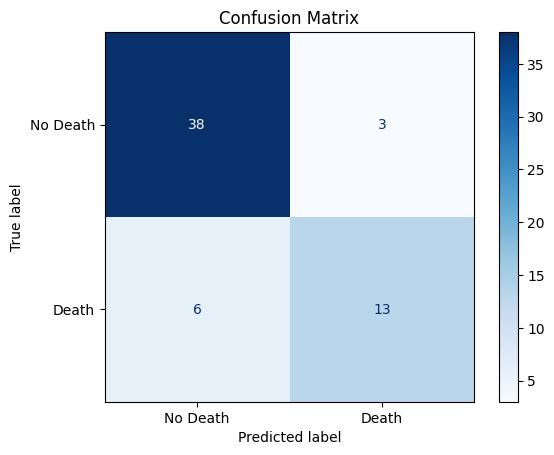

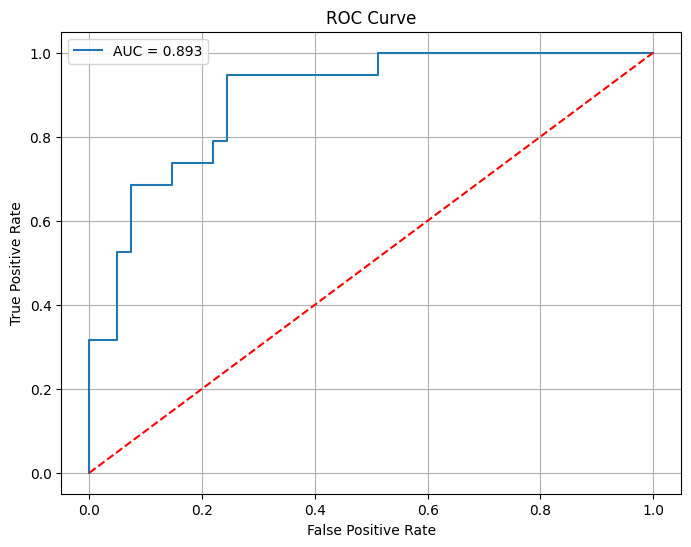

In [ ]:

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]



accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No Death", "Death"]

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()




auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="AUC = %.3f" % auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()


FEATURE IMPORTANCE

In [ ]:


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nFeature Importance")

print(importance)


Feature Importance
                     Feature  Importance
11                      time   32.363137
4          ejection_fraction   15.097258
7           serum_creatinine   14.154548
6                  platelets   12.293824
2   creatinine_phosphokinase    7.767936
8               serum_sodium    4.823807
0                        age    4.646320
9                        sex    4.561947
1                    anaemia    1.572547
10                   smoking    1.230974
3                   diabetes    1.083527
5        high_blood_pressure    0.404173


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

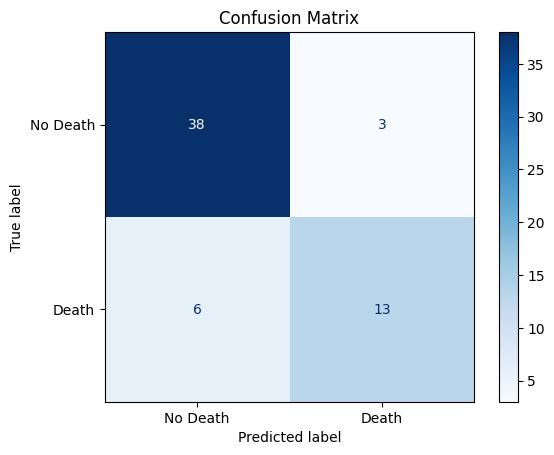

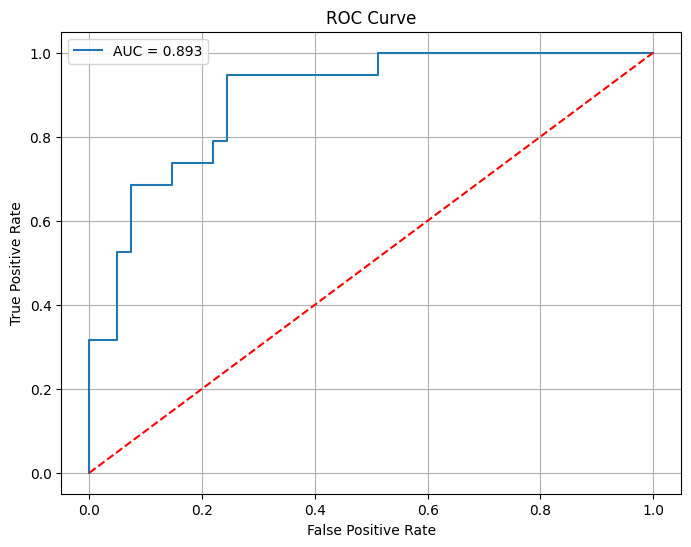


Feature Importance
                     Feature  Importance
11                      time   32.363137
4          ejection_fraction   15.097258
7           serum_creatinine   14.154548
6                  platelets   12.293824
2   creatinine_phosphokinase    7.767936
8               serum_sodium    4.823807
0                        age    4.646320
9                        sex    4.561947
1                    anaemia    1.572547
10                   smoking    1.230974
3                   diabetes    1.083527
5        high_blood_pressure    0.404173


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

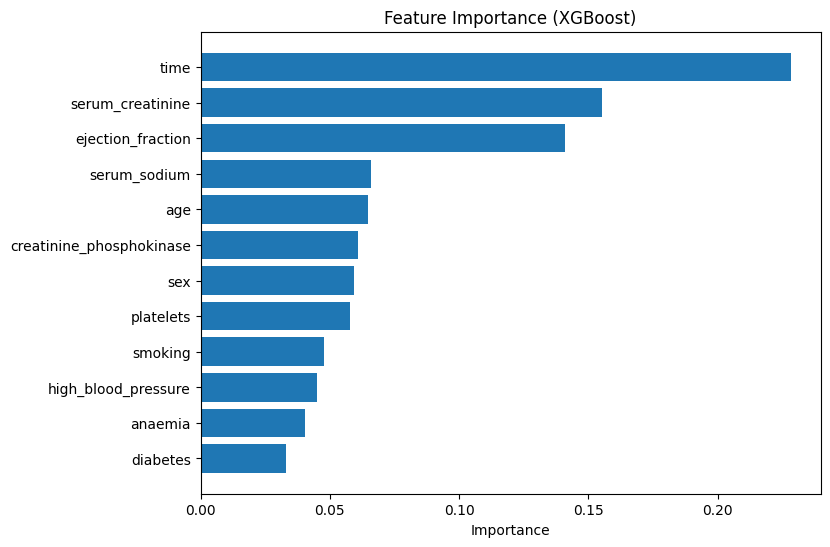

In [ ]:
# Install XGBoost
!pip install xgboost -q

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

# Display first 5 rows
print(df.head())

# Features and Target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy*100,2), "%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature Importance
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importance)

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel("Importance")
plt.title("Feature Importance (XGBoost)")
plt.show()

MINI PROJECT

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

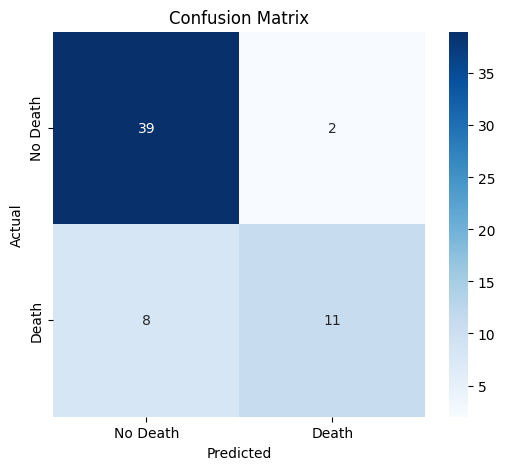

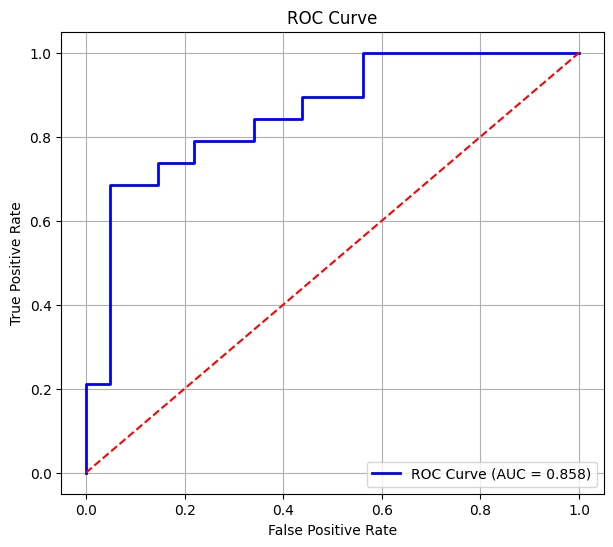

ROC-AUC Score: 0.858


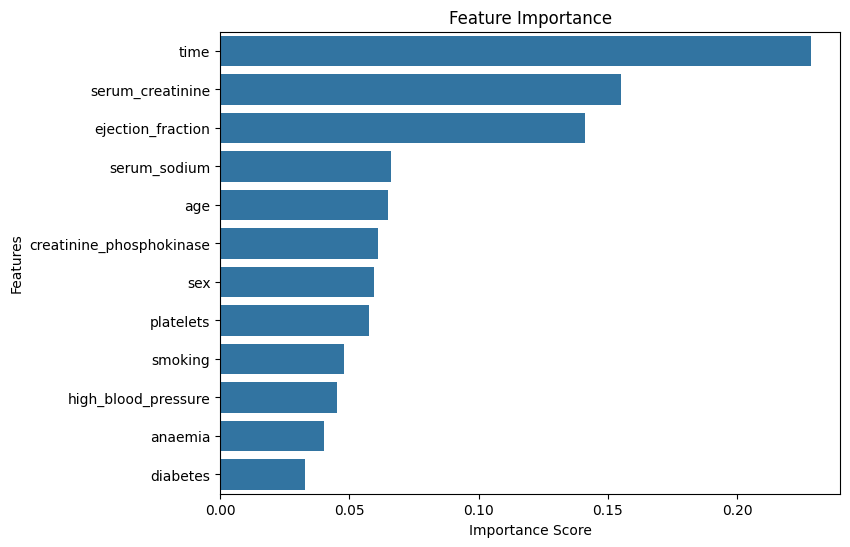

In [ ]:
# Install XGBoost (Google Colab)
!pip install -q xgboost

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

# Display Dataset
print(df.head())

# Features and Target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Build XGBoost Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy = {:.2f}%".format(accuracy*100))

# Classification Report
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Death','Death'],
    yticklabels=['No Death','Death']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label='ROC Curve (AUC = {:.3f})'.format(auc))

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print("ROC-AUC Score:", round(auc,3))

# Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()